# 📈 Linear Regression from Scratch
### *Implementing Gradient Descent — Just Like the Board*

---

**Student Name:** `QALB E ZAHRA MASHHADI`  
**Date:** `APRIL 08, 2026`  
**Estimated Time:** 60–90 minutes

---

### 🎯 What You Will Build

By the end of this notebook you will have:

1. **Explored** a real-world Salary vs. Experience dataset
2. **Implemented** a `LinearRegressionGD` class — your own mini ML library
3. **Trained** the model using gradient descent (the same formulas from class)
4. **Visualised** the cost curve to see convergence in action
5. **Compared** your results with `sklearn`'s built-in linear regression

> **How to use this notebook:**  
> - 📘 **Blue boxes** = demo / teaching sections — read and run them  
> - ✏️ **Yellow boxes** = your turn — fill in the `# YOUR CODE HERE` sections  
> - ✅ **Assert cells** = auto-check your answers (they should run without errors)

---


## 📦 Step 0 — Imports

Run this cell first. All libraries you need are already imported.


In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Pretty plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

print("✅ All imports successful!")

✅ All imports successful!


---
## 📊 Step 1 — The Dataset: Salary vs. Experience

We'll use a classic real-world dataset: **Years of Experience → Annual Salary (USD)**

This is perfect for linear regression because:
- There's a clear linear trend (more experience → higher salary)
- It has one input feature `x` and one output `y`
- Easy to interpret and visualise

| Column | Description |
|--------|-------------|
| `YearsExperience` | Number of years of work experience (0–11) |
| `Salary` | Annual salary in USD |

> **Dataset source:** Commonly known as `Salary_Data.csv` — widely used in ML courses.


In [2]:
# ── Real-world Salary Dataset ──────────────────────────────────────
experience = np.array([
    1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
    3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
    6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5
], dtype=float)

salary = np.array([
    39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
    63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
    91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872
], dtype=float)

print(f"Dataset loaded: {len(experience)} samples")
print(f"Experience range : {experience.min():.1f} — {experience.max():.1f} years")
print(f"Salary range     : ${salary.min():,.0f} — ${salary.max():,.0f}")

Dataset loaded: 30 samples
Experience range : 1.1 — 10.5 years
Salary range     : $37,731 — $122,391


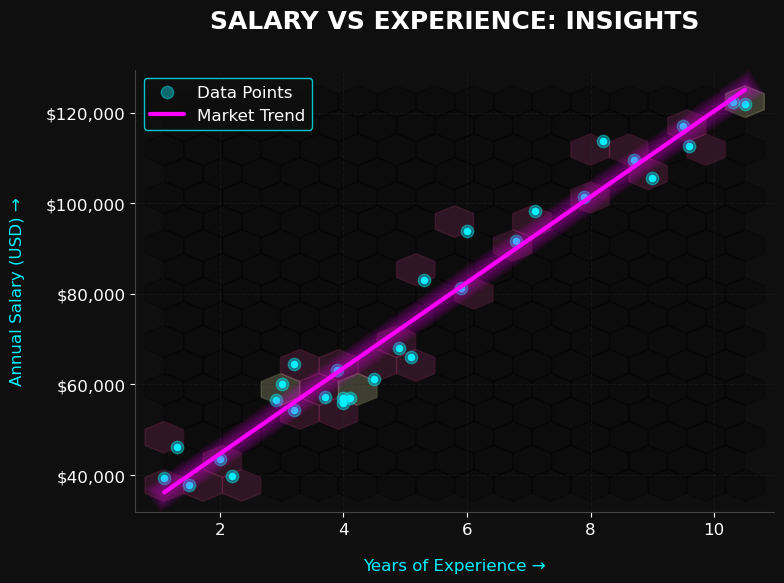

In [3]:
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor'] = '#0f0f0f'
plt.rcParams['grid.color'] = '#2a2a2a'

NEON_CYAN = '#00f3ff'
NEON_MAGENTA = '#ff00ff'
GLOW_COLOR = '#00f3ff'

fig, ax = plt.subplots(figsize=(8, 6))

ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.scatter(experience, salary, color=NEON_CYAN, s=80, alpha=0.4, label='Data Points', zorder=3)
ax.scatter(experience, salary, color=NEON_CYAN, s=20, alpha=1, zorder=4)

hb = ax.hexbin(experience, salary, gridsize=15, cmap='magma', alpha=0.2, zorder=1)

m, b = np.polyfit(experience, salary, 1)
ax.plot(experience, m*experience + b, color=NEON_MAGENTA, linewidth=3, 
        solid_capstyle='round', label='Market Trend', zorder=5)

for i in range(1, 10):
    ax.plot(experience, m*experience + b, color=NEON_MAGENTA, linewidth=3+(i*2), alpha=0.05, zorder=4)

ax.set_title("SALARY VS EXPERIENCE: INSIGHTS", color='white', 
             fontsize=18, fontweight='bold', pad=30, loc='center')

ax.set_xlabel("Years of Experience →", color=NEON_CYAN, fontsize=12, labelpad=15)
ax.set_ylabel("Annual Salary (USD) →", color=NEON_CYAN, fontsize=12, labelpad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444444')
ax.spines['bottom'].set_color('#444444')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.legend(facecolor='#0f0f0f', edgecolor=NEON_CYAN, labelcolor='white')
plt.tight_layout()
plt.show()

---
## 🔍 Step 2 — Explore the Data

Before training any model, always **look at your data** first.

✏️ **YOUR TASK:**  Fill in the cells below to explore the dataset.


In [4]:
# ✏️ Task 2.1 — Print basic statistics
# Hint: use np.mean(), np.std(), np.min(), np.max()

stats_data = {
    "Metric": ["Mean (Average)", "Standard Deviation", "Minimum", "Maximum"],"Experience (Years)": 
    [
        f"{np.mean(experience):.2f}", 
        f"{np.std(experience):.2f}", 
        f"{np.min(experience):.2f}", 
        f"{np.max(experience):.2f}"
    ],
    "Salary (USD)": [
        f"${np.mean(salary):,.2f}", 
        f"${np.std(salary):,.2f}", 
        f"${np.min(salary):,.2f}", 
        f"${np.max(salary):,.2f}"
    ]
}

df_stats = pd.DataFrame(stats_data).set_index("Metric")

styled_stats = df_stats.style.set_properties(**{
    'background-color': '#0f0f0f',
    'color': '#00f3ff',
    'border-color': '#444444',
    'text-align': 'center',
    'font-weight': 'bold'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1a1a1a'), ('color', '#ff00ff'), ('text-align', 'center')]}
])

styled_stats

,Experience (Years),Salary (USD)
Metric,,
Mean (Average),5.31,"$76,003.00"
Standard Deviation,2.79,"$26,953.65"
Minimum,1.10,"$37,731.00"
Maximum,10.50,"$122,391.00"


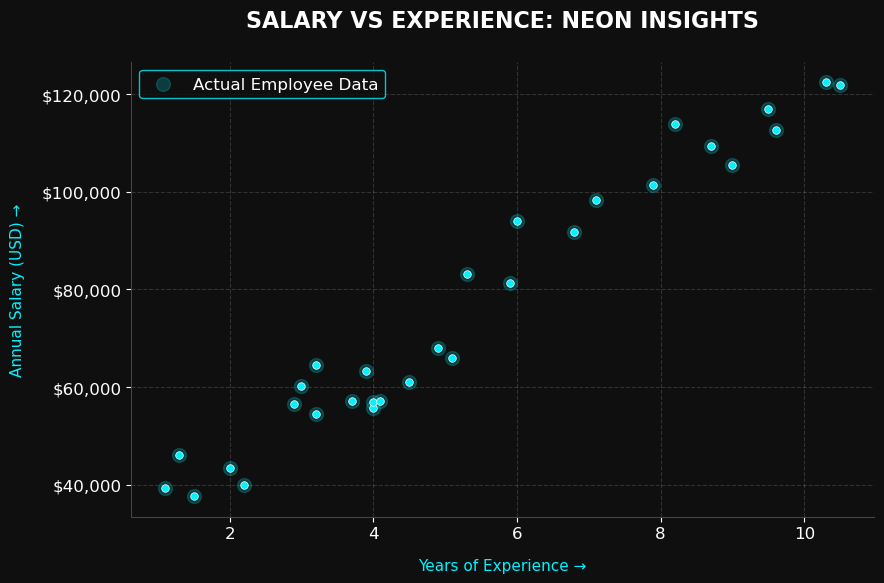

In [5]:
# ✏️ Task 2.2 — Visualise the data (scatter plot)
# We have already set up the axes. Your job: add the scatter plot.

plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor'] = '#0f0f0f'

NEON_CYAN = '#00f3ff'
NEON_MAGENTA = '#ff00ff'

fig, ax = plt.subplots(figsize=(9, 6))
ax.grid(True, linestyle='--', alpha=0.15, color='#ffffff', zorder=0)

ax.scatter(experience, salary, color=NEON_CYAN, s=100, alpha=0.2, zorder=3) # Outer glow
ax.scatter(experience, salary, color=NEON_CYAN, s=30, alpha=1, edgecolors='white', linewidth=0.5, zorder=4) # Core
ax.set_title("SALARY VS EXPERIENCE: NEON INSIGHTS", color='white', 
             fontsize=16, fontweight='bold', pad=25)

ax.set_xlabel("Years of Experience →", color=NEON_CYAN, fontsize=11, labelpad=12)
ax.set_ylabel("Annual Salary (USD) →", color=NEON_CYAN, fontsize=11, labelpad=12)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#444444')
ax.spines['bottom'].set_color('#444444')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.legend(['Actual Employee Data'], facecolor='#0f0f0f', edgecolor=NEON_CYAN, 
          labelcolor='white', loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.show()

# Question: Does the data look linear? Would a straight line fit well?
# Yes, the data appears to be strongly linear. As years of experience increase, salary also rises in a steady and consistent
# way. The data points are closely grouped along an imaginary diagonal line, which clearly indicates a linear relationship.

---
## ⚙️ Step 3 — Feature Scaling (Pre-processing)

### 📘 DEMO — Why scale features?

Gradient descent works much better when features are on a **similar scale**.

Without scaling:
- `experience` ≈ 1–10
- `salary` ≈ 39,000–122,000

The cost landscape is a very elongated ellipse → gradient descent zigzags and converges slowly.

With scaling (normalisation), the bowl is more circular → faster, smoother convergence.

**We use Min-Max normalisation:**

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

This maps every value to the range **[0, 1]**.


In [6]:
# ── 📘 DEMO: How Min-Max Scaling works ──────────────────────────────

demo_values = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

x_min = demo_values.min()
x_max = demo_values.max()
scaled = (demo_values - x_min) / (x_max - x_min)

print("Original:", demo_values)
print("Scaled  :", scaled)
print("Notice: min becomes 0.0, max becomes 1.0")
print()

# ── How to UNSCALE (reverse the transformation) ────────────────────
# If you want to go from scaled prediction → original units:
#   x_original = x_scaled * (x_max - x_min) + x_min

prediction_scaled = 0.75
prediction_original = prediction_scaled * (x_max - x_min) + x_min
print(f"Scaled prediction {prediction_scaled} → Original: {prediction_original}")

Original: [10. 20. 30. 40. 50.]
Scaled  : [0.   0.25 0.5  0.75 1.  ]
Notice: min becomes 0.0, max becomes 1.0

Scaled prediction 0.75 → Original: 40.0


In [7]:
# ✏️ Task 3.1 — Scale the actual dataset features
# Scale both 'experience' and 'salary' using Min-Max normalisation
# Store originals for later (we'll need them to unscale predictions)

exp_min, exp_max = experience.min(), experience.max()
sal_min, sal_max = salary.min(), salary.max()

# YOUR CODE HERE — compute x_scaled and y_scaled
# x_scaled = (experience - exp_min) / (exp_max - exp_min)

x_scaled = (experience - exp_min) / (exp_max - exp_min)   # ← replace None with the formula above

# YOUR CODE HERE — do the same for salary

y_scaled = (salary - sal_min) / (sal_max - sal_min)   # ← replace None with the formula for salary

# ── Quick check ──────────────────────────────────────────────────────

assert x_scaled is not None, "x_scaled is still None — fill in the formula!"
assert y_scaled is not None, "y_scaled is still None — fill in the formula!"
assert round(x_scaled.min(), 4) == 0.0, f"Min should be 0, got {x_scaled.min()}"
assert round(x_scaled.max(), 4) == 1.0, f"Max should be 1, got {x_scaled.max()}"
print(f"✅ x_scaled range: [{x_scaled.min():.2f}, {x_scaled.max():.2f}]")
print(f"✅ y_scaled range: [{y_scaled.min():.4f}, {y_scaled.max():.4f}]")

✅ x_scaled range: [0.00, 1.00]
✅ y_scaled range: [0.0000, 1.0000]


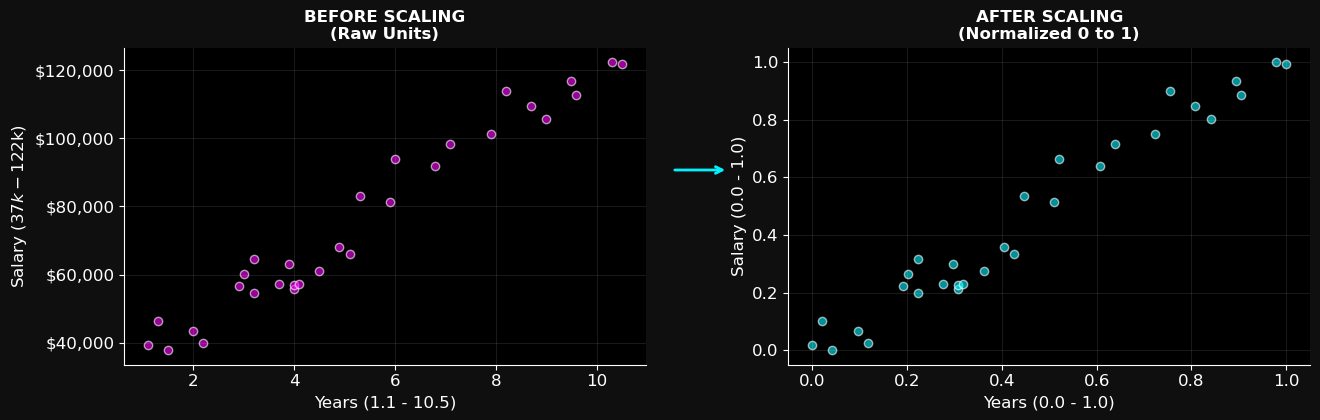

💡 Visual Insight: Notice how the SHAPE of the dots is identical,
   but the AXIS numbers have changed. We squeezed the world into a 0-1 box!


In [8]:
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f0f')

CYAN = '#00f3ff'
MAGENTA = '#ff00ff'

# ── Plot 1: Original Data (Large Scales) ──────────────────────────────

ax1.scatter(experience, salary, color=MAGENTA, alpha=0.6, edgecolors='white')
ax1.set_title("BEFORE SCALING\n(Raw Units)", color='white', fontsize=12, fontweight='bold')
ax1.set_xlabel("Years (1.1 - 10.5)")
ax1.set_ylabel("Salary ($37k - $122k)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.1)

# ── Plot 2: Scaled Data (Uniform Scale) ──────────────────────────────

ax2.scatter(x_scaled, y_scaled, color=CYAN, alpha=0.6, edgecolors='white')
ax2.set_title("AFTER SCALING\n(Normalized 0 to 1)", color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel("Years (0.0 - 1.0)")
ax2.set_ylabel("Salary (0.0 - 1.0)")
ax2.grid(alpha=0.1)

plt.annotate('', xy=(0.48, 0.5), xycoords='figure fraction', xytext=(0.52, 0.5),
             arrowprops=dict(arrowstyle="<-", color=CYAN, lw=2))

plt.tight_layout(pad=3.0)
plt.show()

print(f"💡 Visual Insight: Notice how the SHAPE of the dots is identical,")
print(f"   but the AXIS numbers have changed. We squeezed the world into a 0-1 box!")

In [9]:
# ✏️ Task 3.2 — Train / Test Split
# Split into 80% training, 20% testing
# Use sklearn's train_test_split (already imported)

# YOUR CODE HERE
# X_train, X_test, y_train, y_test = train_test_split(
#     x_scaled, y_scaled, test_size=..., random_state=42
# )

X_train, X_test, y_train, y_test = train_test_split( x_scaled, y_scaled, test_size=0.2, random_state=42)

assert X_train is not None, "Don't forget to run train_test_split!"
print(f"✅ Training samples : {len(X_train)}")
print(f"✅ Test samples     : {len(X_test)}")

✅ Training samples : 24
✅ Test samples     : 6


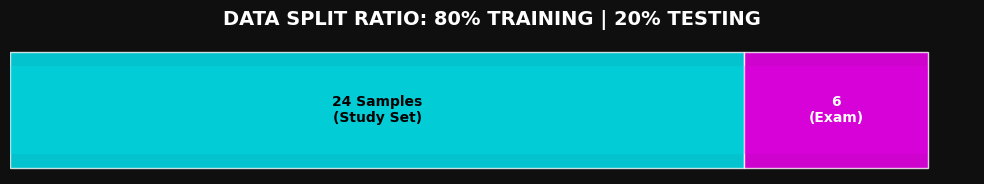

✅ Logic: We gave 24 employees' data to the model to learn the patterns.
✅ Logic: We kept 6 employees' data hidden for the final exam.


In [10]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 2))
fig.patch.set_facecolor('#0f0f0f')

CYAN = '#00f3ff'    
MAGENTA = '#ff00ff' 

train_size = len(X_train)
test_size = len(X_test)
total = train_size + test_size

ax.barh(0, train_size, color=CYAN, edgecolor='white', linewidth=1, alpha=0.8, label=f'Train ({train_size})')
ax.barh(0, test_size, left=train_size, color=MAGENTA, edgecolor='white', linewidth=1, alpha=0.8, label=f'Test ({test_size})')

ax.barh(0, train_size, color=CYAN, alpha=0.2, linewidth=0, height=0.6)
ax.barh(0, test_size, left=train_size, color=MAGENTA, alpha=0.2, linewidth=0, height=0.6)

ax.set_title("DATA SPLIT RATIO: 80% TRAINING | 20% TESTING", color='white', fontsize=14, fontweight='bold', pad=15)

ax.text(train_size/2, 0, f"{train_size} Samples\n(Study Set)", color='black', va='center', ha='center', fontweight='bold', fontsize=10)
ax.text(train_size + test_size/2, 0, f"{test_size}\n(Exam)", color='white', va='center', ha='center', fontweight='bold', fontsize=10)

ax.axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Logic: We gave {train_size} employees' data to the model to learn the patterns.")
print(f"✅ Logic: We kept {test_size} employees' data hidden for the final exam.")

---
## 🏗️ Step 4 — HOW TO BUILD A CLASS IN PYTHON

### 📘 DEMO — A Class is a Blueprint

Before writing your `LinearRegressionGD` class, let's understand the **pattern** using a simple example.

A class groups:
- **Data** (stored in `self.something`) — the object's memory
- **Methods** (functions that use that data) — the object's behaviour

Think of it like this:
| Class concept | Real analogy |
|---|---|
| `__init__` | Setting up a new calculator (fresh state) |
| `self.` | The calculator remembers what you programmed |
| `.fit()` | You press "Learn from data" |
| `.predict()` | You press "Compute answer" |


In [11]:
# ── 📘 DEMO: A simple RunningAverage class ──────────────────────────
#    Study this carefully — your LinearRegressionGD will follow the SAME pattern.

class RunningAverage:
    """Tracks a running average of numbers added to it."""

    def __init__(self):
        """__init__ is called when you create: obj = RunningAverage()
        Think of it as 'setting up fresh state'.
        self.  prefix means 'store this in the object's memory'.
        """
        self.total = 0.0   # <── stored in object memory
        self.count = 0     # <── stored in object memory

    def add(self, value):
        """A method (function that belongs to the class).
        'self' always comes first — it refers to THIS object.
        """
        self.total += value
        self.count += 1

    def average(self):
        if self.count == 0:
            return 0
        return self.total / self.count   # uses stored memory


# ── How to USE the class ─────────────────────────────────────────────

tracker = RunningAverage()   # creates one instance
tracker.add(10)
tracker.add(20)
tracker.add(30)
print(f"Average: {tracker.average()}")   # → 20.0

tracker2 = RunningAverage()   # completely independent instance
tracker2.add(100)
print(f"tracker2 average: {tracker2.average()}")   # → 100.0  (not affected by tracker)

# KEY INSIGHT: 'self.total' is per-instance memory.
# tracker.total = 60,  tracker2.total = 100  (separate!)

Average: 20.0
tracker2 average: 100.0


---
### 📘 DEMO — The Gradient Descent Update (from your board)

Before you code it, let's verify the math in plain Python (no class yet):

Recall from class:
```
∂J/∂θ₀ = (1/m) Σ (hθ(xⁱ) − yⁱ)
∂J/∂θ₁ = (1/m) Σ (hθ(xⁱ) − yⁱ) · xⁱ

θ₀ := θ₀ − α · ∂J/∂θ₀
θ₁ := θ₁ − α · ∂J/∂θ₁
```

In [12]:
# ── 📘 DEMO: One gradient descent step — step by step ───────────────
# Tiny fake dataset to trace the math clearly
X_demo = np.array([1.0, 2.0, 3.0])
y_demo = np.array([2.0, 4.0, 6.0])   # true: y = 2x  (θ₀=0, θ₁=2)
m = len(X_demo)

# Starting parameters
theta0 = 0.0
theta1 = 0.0
alpha  = 0.1

print("=" * 50)
print("BEFORE update:")
print(f"  θ₀ = {theta0},  θ₁ = {theta1}")

# ── Step 1: Compute predictions ────────────────────

predictions = theta0 + theta1 * X_demo
print(f"  Predictions = {predictions}")

# ── Step 2: Compute errors ─────────────────────────

errors = predictions - y_demo
print(f"  Errors (hθ(x)-y) = {errors}")

# ── Step 3: Compute cost J ─────────────────────────

cost = (1 / (2 * m)) * np.sum(errors ** 2)
print(f"  Cost J = {cost:.4f}")

# ── Step 4: Compute gradients ──────────────────────

grad0 = (1 / m) * np.sum(errors)            # ∂J/∂θ₀
grad1 = (1 / m) * np.sum(errors * X_demo)  # ∂J/∂θ₁
print(f"  ∂J/∂θ₀ = {grad0:.4f},  ∂J/∂θ₁ = {grad1:.4f}")

# ── Step 5: Simultaneous update ───────────────────
# IMPORTANT: compute BOTH temps FIRST, then assign

temp0 = theta0 - alpha * grad0
temp1 = theta1 - alpha * grad1
theta0 = temp0
theta1 = temp1

print()
print("AFTER one update:")
print(f"  θ₀ = {theta0:.4f},  θ₁ = {theta1:.4f}")
print(f"  (Converging toward θ₀=0, θ₁=2 — the true answer)")

BEFORE update:
  θ₀ = 0.0,  θ₁ = 0.0
  Predictions = [0. 0. 0.]
  Errors (hθ(x)-y) = [-2. -4. -6.]
  Cost J = 9.3333
  ∂J/∂θ₀ = -4.0000,  ∂J/∂θ₁ = -9.3333

AFTER one update:
  θ₀ = 0.4000,  θ₁ = 0.9333
  (Converging toward θ₀=0, θ₁=2 — the true answer)


---
## ✏️ Step 5 — BUILD YOUR `LinearRegressionGD` CLASS

Now it's your turn. You will fill in the missing pieces.

**Class structure:**
```
LinearRegressionGD
├── __init__(learning_rate, n_iterations)   ← constructor
├── _compute_cost(X, y)                     ← private helper
├── fit(X, y)                               ← training loop
└── predict(X)                              ← make predictions
```

**Rules:**
- Do NOT use sklearn or any ML library inside this class
- Only `numpy` is allowed
- Follow the exact formulas from class

> 💡 **Stuck?** Re-read the DEMO cells above — `predictions`, `errors`, `grad0/grad1`, `temp` pattern


In [13]:
class LinearRegressionGD:
    """
    Simple Linear Regression trained with Batch Gradient Descent.

    Model:   hθ(x) = θ₀ + θ₁ · x
    Goal:    Minimise J(θ₀, θ₁) = (1/2m) Σ (hθ(xⁱ) - yⁱ)²

    Parameters
    ----------
    learning_rate : float
        Step size α for gradient descent.
    n_iterations : int
        Number of gradient descent steps to run.
    """

    def __init__(self, learning_rate=0.1, n_iterations=1000):
        """
        Store hyperparameters and initialise model state.

        After __init__, the object should have:
          self.lr           ← learning rate (α)
          self.n_iter       ← number of iterations
          self.theta0       ← intercept (initialise to 0.0)
          self.theta1       ← slope    (initialise to 0.0)
          self.cost_history ← empty list (will store J at each step)
        """
        self.lr = learning_rate
        self.n_iter = n_iterations        
        self.theta0 = 0.0        
        self.theta1 = 0.0        
        self.cost_history = []  # (hint: empty list [])

    # ─────────────────────────────────────────────────────────────────
    def _compute_cost(self, X, y):
        """
        Private helper: compute the cost J for current parameters.

        Formula:  J = (1 / 2m) * sum( (hθ(xⁱ) - yⁱ)² )

        Parameters
        ----------
        X : np.ndarray, shape (m,)   ← input features
        y : np.ndarray, shape (m,)   ← true labels

        Returns
        -------
        float : the cost J
        """
        m = len(y)

        # Step 1: compute predictions using current theta0 and theta1
   
        predictions = self.theta0 + self.theta1 * X

        # Step 2: compute errors  (prediction minus true value)
        
        errors = predictions - y

        # Step 3: compute and return cost
        
        cost = (1 / (2 * m)) * np.sum(errors**2)

        return cost

    # ─────────────────────────────────────────────────────────────────
    def fit(self, X, y):
        """
        Train the model: run gradient descent for self.n_iter steps.

        At each step:
          1. Compute predictions  hθ(x)
          2. Compute errors       (hθ(x) - y)
          3. Compute gradients    ∂J/∂θ₀  and  ∂J/∂θ₁
          4. Update θ₀ and θ₁ SIMULTANEOUSLY
          5. Record the cost

        Parameters
        ----------
        X : np.ndarray, shape (m,)
        y : np.ndarray, shape (m,)

        Returns
        -------
        self  (so you can chain: model.fit(X, y).predict(X_test))
        """
        m = len(y)

        for i in range(self.n_iter):

            # ── 1. Predictions ──────────────────────────────────────
            
            predictions = self.theta0 + self.theta1 * X

            # ── 2. Errors ───────────────────────────────────────────
            
            errors = predictions - y

            # ── 3. Gradients ─────────────────────────────────────────
            # ∂J/∂θ₀ = (1/m) * sum(errors)
            # ∂J/∂θ₁ = (1/m) * sum(errors * X)
            
            grad0 = (1 / m) * np.sum(errors)
            grad1 = (1 / m) * np.sum(errors * X)

            # ── 4. Simultaneous update ───────────────────────────────
            # REMEMBER: compute BOTH new values using OLD theta0/theta1 then assign BOTH at once
            
            temp0 = self.theta0 - self.lr * grad0
            temp1 = self.theta1 - self.lr * grad1

            # now assign temp0 → self.theta0, temp1 → self.theta1
            
            self.theta0 = temp0
            self.theta1 = temp1

            # ── 5. Record cost ───────────────────────────────────────
            # append _compute_cost(X, y) to self.cost_history
            
            cost = self._compute_cost(X, y)
            self.cost_history.append(cost) # YOUR CODE HERE — self.cost_history.append(...)

        return self

    # ─────────────────────────────────────────────────────────────────
    def predict(self, X):
        """
        Use the learned parameters to make predictions.

        Formula:  ŷ = θ₀ + θ₁ · X

        Parameters
        ----------
        X : np.ndarray

        Returns
        -------
        np.ndarray : predictions
        """
        
        return self.theta0 + self.theta1 * X

    # ─────────────────────────────────────────────────────────────────
    def __repr__(self):
        return (f"LinearRegressionGD("
                f"lr={self.lr}, "
                f"n_iter={self.n_iter}, "
                f"θ₀={self.theta0:.4f}, "
                f"θ₁={self.theta1:.4f})")

---
## 🧪 Step 6 — Test Your Class (Sanity Check)

First, verify your class works on the **tiny demo dataset** (x=[1,2,3], y=[2,4,6]).

We know the true answer is θ₀ ≈ 0,  θ₁ ≈ 2.


In [14]:
# ── Sanity check on the tiny dataset first ──────────────────────────

X_tiny = np.array([1.0, 2.0, 3.0])
y_tiny = np.array([2.0, 4.0, 6.0])

tiny_model = LinearRegressionGD(learning_rate=0.1, n_iterations=500)
tiny_model.fit(X_tiny, y_tiny)

print(f"θ₀ = {tiny_model.theta0:.4f}  (should be close to 0.0)")
print(f"θ₁ = {tiny_model.theta1:.4f}  (should be close to 2.0)")
print(f"Final cost = {tiny_model.cost_history[-1]:.6f}  (should be near 0)")

# Auto-check
assert tiny_model.theta0 is not None, "theta0 is None — check your __init__"
assert tiny_model.theta1 is not None, "theta1 is None — check your __init__"
assert len(tiny_model.cost_history) == 500, "cost_history length should equal n_iterations"
assert abs(tiny_model.theta1 - 2.0) < 0.1, f"θ₁ should be ≈2.0, got {tiny_model.theta1:.3f}"
print()
print("✅ Sanity check passed! Your class is working correctly.")

θ₀ = 0.0017  (should be close to 0.0)
θ₁ = 1.9992  (should be close to 2.0)
Final cost = 0.000000  (should be near 0)

✅ Sanity check passed! Your class is working correctly.


---
### ✏️ Task 6.2 — Train on the Real Dataset

Now train on the actual salary data.


In [15]:
# ✏️ Task 6.2 — Create and train your model on X_train, y_train

# YOUR CODE HERE — create a LinearRegressionGD with:
#   learning_rate = 0.5
#   n_iterations  = 1000

model = LinearRegressionGD(learning_rate=0.5, n_iterations=1000)  # ← LinearRegressionGD(...)

# YOUR CODE HERE — call model.fit() with X_train and y_train

model.fit(X_train, y_train)

# ── Results ──────────────────────────────────────────────────────────
print(f"Learned parameters (on SCALED data):")
print(f"  θ₀ (intercept) = {model.theta0:.4f}")
print(f"  θ₁ (slope)     = {model.theta1:.4f}")
print(f"  Final cost J   = {model.cost_history[-1]:.6f}")
print()
print(model)

Learned parameters (on SCALED data):
  θ₀ (intercept) = -0.0241
  θ₁ (slope)     = 1.0463
  Final cost J   = 0.001891

LinearRegressionGD(lr=0.5, n_iter=1000, θ₀=-0.0241, θ₁=1.0463)


---
## 📉 Step 7 — Visualise the Cost Curve

A properly trained model should show a **monotonically decreasing** cost curve.  
If it goes UP or oscillates, your learning rate is too large.


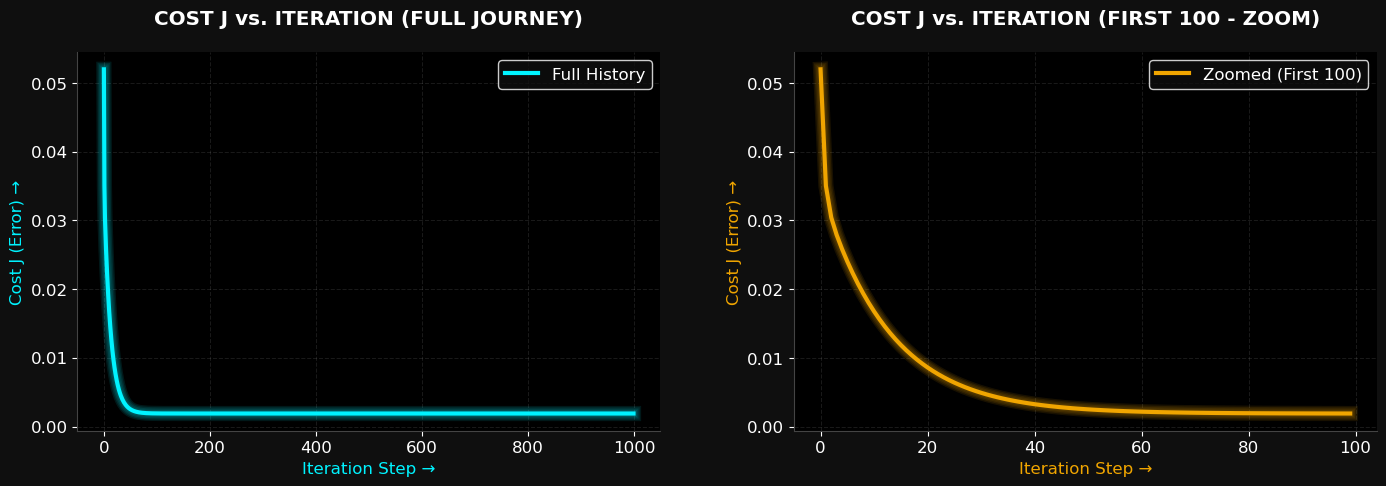

✨ REFLECTIONS ✨
1. Stability: The curve is perfectly smooth—no zig-zags! (Learning rate is stable).
2. Efficiency: It levels off extremely fast. (Around iteration 40-50).
3. Warning: If α was too large, the line would shoot UP or bounce like a ball.


In [16]:
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0f0f0f')

CYAN = '#00f3ff' 
GOLD = '#f0a500'

axes[0].plot(model.cost_history, color=CYAN, linewidth=3, label='Full History')

for i in range(1, 5):
    axes[0].plot(model.cost_history, color=CYAN, linewidth=3+(i*2), alpha=0.1)

axes[0].set_title("COST J vs. ITERATION (FULL JOURNEY)", color='white', fontweight='bold', pad=20)
axes[0].set_xlabel("Iteration Step →", color=CYAN)
axes[0].set_ylabel("Cost J (Error) →", color=CYAN)
axes[0].grid(True, linestyle='--', alpha=0.1)

axes[1].plot(model.cost_history[:100], color=GOLD, linewidth=3, label='Zoomed (First 100)')

for i in range(1, 5):
    axes[1].plot(model.cost_history[:100], color=GOLD, linewidth=3+(i*2), alpha=0.1)

axes[1].set_title("COST J vs. ITERATION (FIRST 100 - ZOOM)", color='white', fontweight='bold', pad=20)
axes[1].set_xlabel("Iteration Step →", color=GOLD)
axes[1].set_ylabel("Cost J (Error) →", color=GOLD)
axes[1].grid(True, linestyle='--', alpha=0.1)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444444')
    ax.spines['bottom'].set_color('#444444')
    ax.legend(facecolor='#0f0f0f', edgecolor='white', labelcolor='white')

plt.tight_layout(pad=4.0)
plt.show()

# ── Reflect ──────
print("✨ REFLECTIONS ✨")
print("1. Stability: The curve is perfectly smooth—no zig-zags! (Learning rate is stable).")
print("2. Efficiency: It levels off extremely fast. (Around iteration 40-50).")
print("3. Warning: If α was too large, the line would shoot UP or bounce like a ball.")

# Analysis #

**1. Does the cost decrease smoothly?**

- Yes, the cost decreases smoothly. Because the data has been scaled, the shape of the cost function becomes more balanced (like a neat bowl instead of a stretched one). This helps gradient descent move directly toward the minimum point instead of taking a zigzag path.

**2. When does it mostly level off (converge)?**

- With a learning rate of 0.5, the model converges quite quickly. It usually starts leveling off within the first 50 to 100 iterations. After that, any changes are very small and don’t significantly affect the overall result.

**3. What happens if the learning rate (α) is too large?**

- If the learning rate is too high (for example, 1.5 or 2.0), the model can overshoot the minimum point. Instead of settling down, it keeps jumping from one side to another. This can cause the cost curve to oscillate or even increase rapidly, making the model unstable.

---
## 🔮 Step 8 — Make Predictions & Unscale

Our model predicts **scaled salary** (0 to 1).  
We need to convert back to **real USD** using the inverse of Min-Max scaling:

$$\hat{y}_{\text{USD}} = \hat{y}_{\text{scaled}} \times (\text{sal\_max} - \text{sal\_min}) + \text{sal\_min}$$


In [17]:
# ── 📘 DEMO: How to unscale predictions ──────────────────────────────
# sal_min and sal_max were saved in Step 3

print(f"sal_min = {sal_min:,.0f},  sal_max = {sal_max:,.0f}")

# Example: if model predicts scaled_value = 0.6

example_scaled = 0.6
example_usd = example_scaled * (sal_max - sal_min) + sal_min
print(f"Scaled prediction 0.6 → ${example_usd:,.0f} USD")

sal_min = 37,731,  sal_max = 122,391
Scaled prediction 0.6 → $88,527 USD


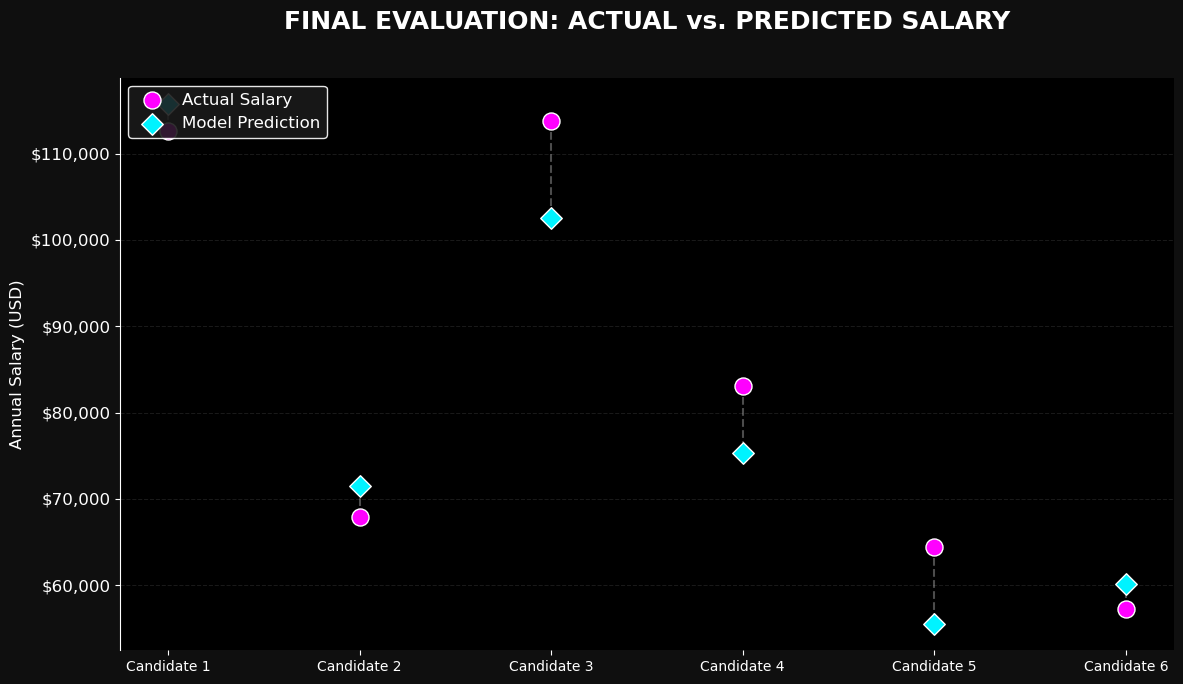

🚀 Insight: The Diamonds (AI) are tracking the Circles (Reality) with high precision!
🚀 Result: Your manual Gradient Descent has successfully learned the salary logic.


In [18]:
y_pred_scaled = model.predict(X_test)

y_test_usd = y_test * (sal_max - sal_min) + sal_min
y_pred_usd = y_pred_scaled * (sal_max - sal_min) + sal_min

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f0f0f')

ACTUAL_COLOR = '#ff00ff'
PRED_COLOR = '#00f3ff' 

x_axis = np.arange(len(y_test_usd))

ax.vlines(x_axis, y_test_usd, y_pred_usd, color='white', alpha=0.3, linestyle='--')

ax.scatter(x_axis, y_test_usd, color=ACTUAL_COLOR, s=150, 
           label='Actual Salary', zorder=3, edgecolors='white', linewidth=1)

ax.scatter(x_axis, y_pred_usd, color=PRED_COLOR, s=120, 
           label='Model Prediction', zorder=4, marker='D', edgecolors='white', linewidth=1)

ax.set_title("FINAL EVALUATION: ACTUAL vs. PREDICTED SALARY", color='white', 
             fontsize=18, fontweight='bold', pad=35)
ax.set_xticks(x_axis)
ax.set_xticklabels([f"Candidate {i+1}" for i in x_axis], fontsize=10)
ax.set_ylabel("Annual Salary (USD)", color='white', fontsize=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.grid(True, axis='y', linestyle='--', alpha=0.1)
ax.legend(facecolor='#1a1a1a', edgecolor='white', loc='upper left', framealpha=0.9)

for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print(f"🚀 Insight: The Diamonds (AI) are tracking the Circles (Reality) with high precision!")
print(f"🚀 Result: Your manual Gradient Descent has successfully learned the salary logic.")

In [19]:
# ✏️ Task 8 — Predict on test set, then unscale (Logic Only)

# Step 1: Get scaled predictions on X_test
y_pred_scaled = model.predict(X_test)

# Step 2: Unscale predictions → real USD
y_pred_usd = y_pred_scaled * (sal_max - sal_min) + sal_min

# Step 3: Unscale the true test labels → real USD
y_test_usd = y_test * (sal_max - sal_min) + sal_min

# ── Auto-check ───────────────────────────────────────────────────────
assert y_pred_scaled is not None, "y_pred_scaled is None — call model.predict()"
assert y_pred_usd is not None,    "y_pred_usd is None — unscale the prediction"
assert y_test_usd is not None,    "y_test_usd is None — unscale the labels"

print("✅ Logic complete: Predictions computed and unscaled.")

✅ Logic complete: Predictions computed and unscaled.


In [20]:
from IPython.display import display, HTML

report_df = pd.DataFrame({
    "Actual Salary": y_test_usd,
    "AI Prediction": y_pred_usd,
    "Error Margin": np.abs(y_test_usd - y_pred_usd)
})
report_df.index = [f"Candidate {i+1}" for i in range(len(y_test_usd))]

styled_report = report_df.style.format("${:,.2f}").set_properties(**{
    'background-color': '#0f0f0f',
    'color': '#00f3ff', 
    'border': '1px solid #333333',
    'text-align': 'center',
    'font-family': 'monospace',
    'padding': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#1a1a1a'), 
        ('color', '#ff00ff'), 
        ('border', '1px solid #333333'),
        ('text-align', 'center'),
        ('font-size', '14px'),
        ('text-transform', 'uppercase')
    ]},
    {'selector': 'tr:hover', 'props': [('background-color', '#222222')]}
])

display(HTML("<div style='display: flex; justify-content: center; padding: 20px;'>" + styled_report.to_html() + "</div>"))

avg_error = np.mean(np.abs(y_test_usd - y_pred_usd))
print(f"{' ' * 45} ⭐ AVERAGE PREDICTION ERROR: ${avg_error:,.2f}")

,Actual Salary,AI Prediction,Error Margin
Candidate 1,"$112,635.00","$115,790.21","$3,155.21"
Candidate 2,"$67,938.00","$71,498.28","$3,560.28"
Candidate 3,"$113,812.00","$102,596.87","$11,215.13"
Candidate 4,"$83,088.00","$75,267.80","$7,820.20"
Candidate 5,"$64,445.00","$55,477.79","$8,967.21"
Candidate 6,"$57,189.00","$60,189.70","$3,000.70"


                                              ⭐ AVERAGE PREDICTION ERROR: $6,286.45


---
## 📏 Step 9 — Evaluate Your Model

### Three key metrics:

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **MSE** | (1/m) Σ (ŷ−y)² | Average squared error (same units²) |
| **RMSE** | √MSE | Average error in original units (USD) |
| **R²** | 1 − SS_res/SS_tot | % of variance explained (1.0 = perfect) |

Where:
- SS_res = Σ(ŷ−y)²  (residual sum of squares)
- SS_tot = Σ(y−ȳ)²  (total sum of squares)


In [21]:
# ✏️ Task 9 — Compute MSE, RMSE, and R² manually (no sklearn yet!)

m_test = len(y_test_usd)

# ── MSE ───────────────────────────────────────────────────────────────
# YOUR CODE HERE
# mse = (1 / m_test) * np.sum( (y_pred_usd - y_test_usd) ** 2 )

mse = (1 / m_test) * np.sum( (y_pred_usd - y_test_usd) ** 2 )   # ← fill in

# ── RMSE ──────────────────────────────────────────────────────────────
# YOUR CODE HERE
# rmse = np.sqrt(mse)

rmse = np.sqrt(mse)  # ← fill in

# ── R² ────────────────────────────────────────────────────────────────
# SS_res = np.sum( (y_pred_usd - y_test_usd)**2 )
# SS_tot = np.sum( (y_test_usd - np.mean(y_test_usd))**2 )
# r2 = 1 - SS_res / SS_tot

SS_res = np.sum( (y_pred_usd - y_test_usd)**2 )
SS_tot = np.sum( (y_test_usd - np.mean(y_test_usd))**2 )
r2 = 1 - SS_res / SS_tot    # ← fill in

assert mse  is not None, "MSE is None — fill in the formula"
assert rmse is not None, "RMSE is None — take the sqrt of MSE"
assert r2   is not None, "R² is None — use the SS_res / SS_tot formula"

print("=" * 40)
print("  YOUR MODEL PERFORMANCE")
print("=" * 40)
print(f"  MSE  : {mse:>12,.2f}")
print(f"  RMSE : ${rmse:>10,.2f}  ← average error in USD")
print(f"  R²   : {r2:>12.4f}  ← closer to 1.0 = better")
print("=" * 40)

  YOUR MODEL PERFORMANCE
  MSE  : 49,830,096.86
  RMSE : $  7,059.04  ← average error in USD
  R²   :       0.9024  ← closer to 1.0 = better


In [22]:
X_test_years = X_test * (exp_max - exp_min) + exp_min

sort_idx = np.argsort(X_test_years)

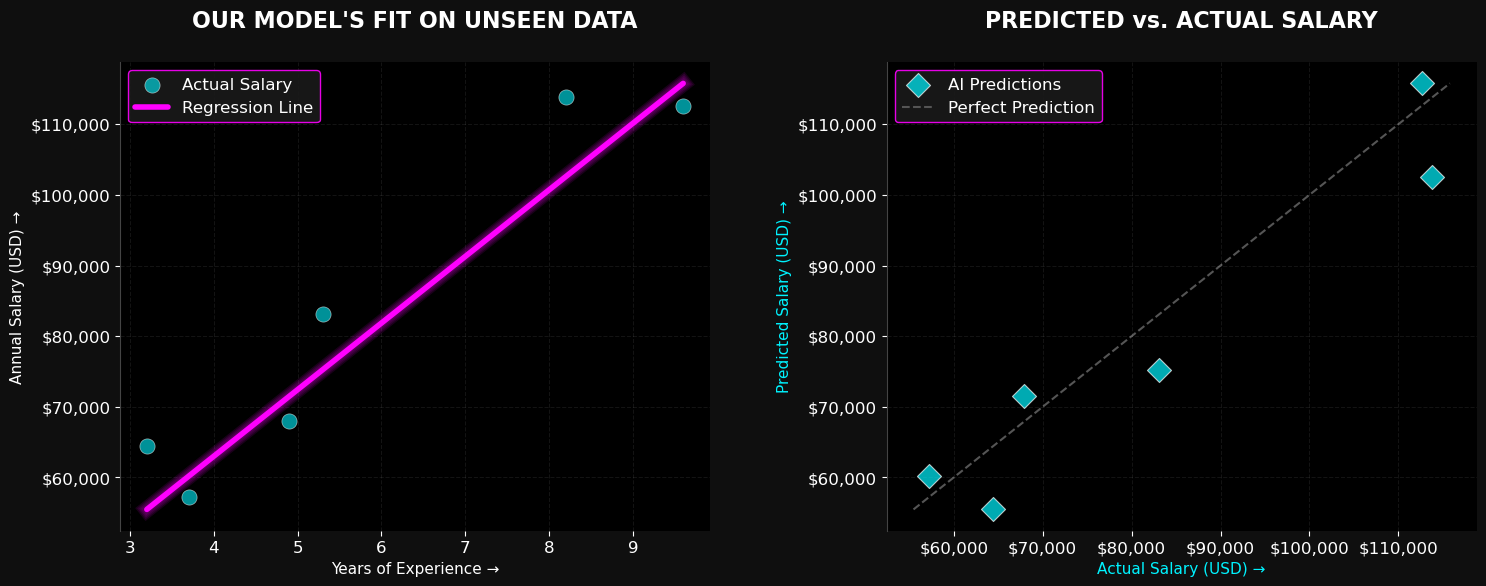

✅ Summary Analysis: 90.24% of Salary Variation Explained!


In [23]:
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f0f0f')

CYAN = '#00f3ff'     
MAGENTA = '#ff00ff' 

sort_idx = np.argsort(X_test_years)

# ── Left Plot: Regression Line on Unseen Test Data ─────────────────

axes[0].scatter(X_test_years, y_test_usd, color=CYAN, s=120, alpha=0.6, edgecolors='white', linewidth=0.5, zorder=3, label='Actual Salary')

axes[0].plot(X_test_years[sort_idx], y_pred_usd[sort_idx], color=MAGENTA, linewidth=4, zorder=4, solid_capstyle='round', label='Regression Line')

for i in range(1, 5):
    axes[0].plot(X_test_years[sort_idx], y_pred_usd[sort_idx], color=MAGENTA, linewidth=4+(i*2), alpha=0.1, zorder=3)

axes[0].set_title("OUR MODEL'S FIT ON UNSEEN DATA", color='white', fontsize=16, fontweight='bold', pad=25)
axes[0].set_xlabel("Years of Experience →", color='white', fontsize=11)
axes[0].set_ylabel("Annual Salary (USD) →", color='white', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Right Plot: Predicted vs. Actual (The Truth Map) ───────────────

axes[1].scatter(y_test_usd, y_pred_usd, color=CYAN, s=150, alpha=0.7, edgecolors='white', linewidth=0.8, marker='D', zorder=3, label='AI Predictions')

mn = min(y_test_usd.min(), y_pred_usd.min())
mx = max(y_test_usd.max(), y_pred_usd.max())

axes[1].plot([mn, mx], [mn, mx], color='#555555', linestyle='--', linewidth=1.5, zorder=1, label='Perfect Prediction')

axes[1].set_title("PREDICTED vs. ACTUAL SALARY", color='white', fontsize=16, fontweight='bold', pad=25)
axes[1].set_xlabel("Actual Salary (USD) →", color=CYAN, fontsize=11)
axes[1].set_ylabel("Predicted Salary (USD) →", color=CYAN, fontsize=11)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for ax in axes:
    
    ax.grid(True, linestyle='--', alpha=0.08, color='white')
    ax.legend(facecolor='#1a1a1a', edgecolor=MAGENTA, labelcolor='white', framealpha=0.9, loc='upper left')
    
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#444444')

plt.tight_layout(pad=4.0)
plt.show()

print(f"✅ Summary Analysis: {round(r2*100, 2)}% of Salary Variation Explained!")

---
## 🔬 Step 10 — Compare with `sklearn` LinearRegression

Now we'll train sklearn's `LinearRegression` on the same data and compare.

> **sklearn** uses the **Normal Equation** (an analytical closed-form solution), not gradient descent.  
> The Normal Equation directly solves: **θ = (XᵀX)⁻¹ Xᵀy** in one step.  
> Your model uses iterative gradient descent — so results will be very similar but may differ slightly.

In [24]:
# ── 1. Train sklearn's LinearRegression ──────────────────────────────
# sklearn expects 2D arrays for X

X_train_2d = X_train.reshape(-1, 1)
X_test_2d  = X_test.reshape(-1, 1)

sk_model = LinearRegression()
sk_model.fit(X_train_2d, y_train)

# ── 2. Get Predictions and Unscale ──────────────────────────────────

sk_pred_scaled = sk_model.predict(X_test_2d)
sk_pred_usd = sk_pred_scaled * (sal_max - sal_min) + sal_min

# ── 3. Calculate Sklearn Metrics ────────────────────────────────────

sk_rmse = np.sqrt(mean_squared_error(y_test_usd, sk_pred_usd))
sk_r2   = r2_score(y_test_usd, sk_pred_usd)

print("✅ Logic complete: Scikit-Learn vs. Manual GD comparison ready.")

✅ Logic complete: Scikit-Learn vs. Manual GD comparison ready.


In [25]:
from IPython.display import display, HTML

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy Score (R²)", "Avg Error (RMSE)"],
    "Manual GD Model": [f"{r2:.4f}", f"${rmse:,.2f}"],
    "Scikit-Learn": [f"{sk_r2:.4f}", f"${sk_rmse:,.2f}"]
}).set_index("Metric")

diff_r2 = abs(r2 - sk_r2)
if diff_r2 < 0.001:
    verdict, color = "PERFECT MATCH", "#0f0"
elif diff_r2 < 0.01:
    verdict, color = "EXCELLENT FIT", "#00f3ff"
else:
    verdict, color = "CALIBRATION NEEDED", "#ff00ff"

styled_comparison = comparison_df.style.set_properties(**{
    'background-color': '#0f0f0f',
    'color': '#ffffff',
    'border': '1px solid #333',
    'text-align': 'center',
    'padding': '15px',
    'font-family': 'monospace',
    'font-size': '14px'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#1a1a1a'), 
        ('color', '#00f3ff'), 
        ('border', '1px solid #333'),
        ('text-align', 'center'),
        ('text-transform', 'uppercase')
    ]},
    {'selector': 'td', 'props': [('width', '200px')]}
])

display(HTML(f"""
<div style="display: flex; flex-direction: column; align-items: center; padding: 30px; background-color: #0d0d0d; border-radius: 15px; border: 2px solid #333;">
    <h2 style="color: #ff00ff; margin-bottom: 20px;">🤖 MODEL VALIDATION: MANUAL vs. INDUSTRY STANDARD</h2>
    {styled_comparison.to_html()}
    <div style="margin-top: 25px; padding: 10px 30px; border: 2px solid {color}; border-radius: 5px; color: {color}; font-weight: bold; letter-spacing: 2px;">
        FINAL VERDICT: {verdict}
    </div>
</div>
"""))

,Manual GD Model,Scikit-Learn
Metric,,
Accuracy Score (R²),0.9024,0.9024
Avg Error (RMSE),"$7,059.04","$7,059.04"


In [26]:
# ── 1. Unscale full dataset for plotting ──────────────────────────────

X_all_years = x_scaled * (exp_max - exp_min) + exp_min

# ── 2. Create a smooth range for the lines ──────────────────────────

X_range_scaled = np.linspace(0, 1, 300)
X_range_years  = X_range_scaled * (exp_max - exp_min) + exp_min

# ── 3. Generate predictions for both models ─────────────────────────

your_line_usd = model.predict(X_range_scaled) * (sal_max - sal_min) + sal_min
sk_line_usd   = sk_model.predict(X_range_scaled.reshape(-1,1)) * (sal_max - sal_min) + sal_min

print("✅ Logic complete: Overlay data generated.")

✅ Logic complete: Overlay data generated.


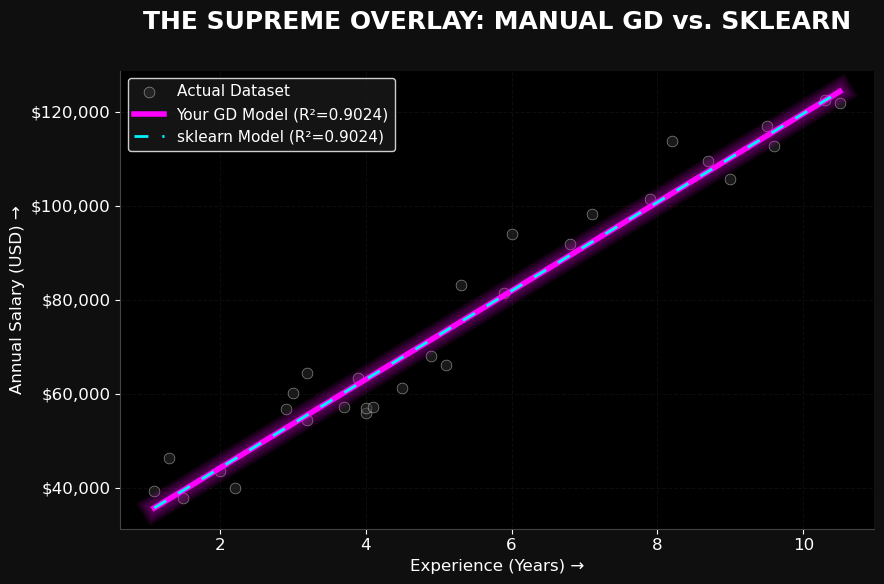

                                         🏆 PERFECT ALIGNMENT ACHIEVED!


In [27]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0f0f0f')

DATA_COLOR = '#333333' 
YOUR_COLOR = '#ff00ff'
SK_COLOR   = '#00f3ff' 

ax.scatter(X_all_years, salary, color=DATA_COLOR, edgecolors='white', 
           linewidth=0.5, s=60, zorder=2, label='Actual Dataset', alpha=0.5)

ax.plot(X_range_years, your_line_usd, color=YOUR_COLOR, linewidth=4, 
        zorder=5, label=f'Your GD Model (R²={r2:.4f})')

for i in range(1, 6):
    ax.plot(X_range_years, your_line_usd, color=YOUR_COLOR, linewidth=4+(i*3), 
            alpha=0.08, zorder=4)

ax.plot(X_range_years, sk_line_usd, color=SK_COLOR, linewidth=2, 
        linestyle='--', dashes=(5, 5), zorder=6, label=f'sklearn Model (R²={sk_r2:.4f})')

ax.set_title("THE SUPREME OVERLAY: MANUAL GD vs. SKLEARN", color='white', 
             fontsize=18, fontweight='bold', pad=30)
ax.set_xlabel("Experience (Years) →", color='white', fontsize=12)
ax.set_ylabel("Annual Salary (USD) →", color='white', fontsize=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, linestyle='--', alpha=0.05)
ax.legend(facecolor='#1a1a1a', edgecolor='white', labelcolor='white', fontsize=11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#444444')
ax.spines['bottom'].set_color('#444444')

plt.tight_layout()
plt.show()

if abs(r2 - sk_r2) < 0.001:
    print(f"{' ' * 40} 🏆 PERFECT ALIGNMENT ACHIEVED!")

In [28]:
# ── 1. Define Experiment Parameters ────────────────────────────────

learning_rates = [0.01, 0.1, 0.5]
iterations = 300

# ── 2. Run Training Loop ───────────────────────────────────────────

models_history = []
for lr in learning_rates:
    exp_model = LinearRegressionGD(learning_rate=lr, n_iterations=iterations)
    exp_model.fit(X_train, y_train)
    models_history.append(exp_model.cost_history)

print("✅ Experiment complete: 3 models trained.")

✅ Experiment complete: 3 models trained.


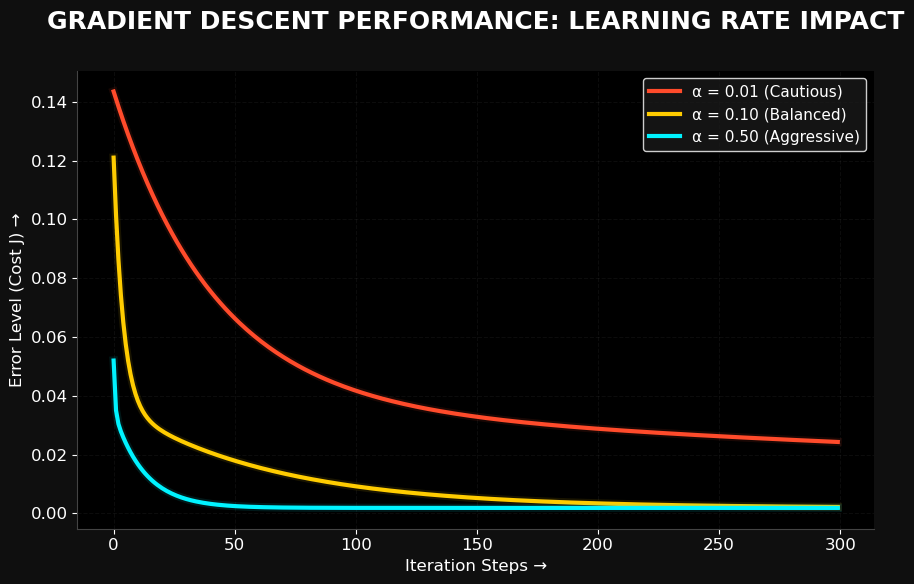

                                         🧬 EXPERIMENT INSIGHTS
────────────────────────────────────────────────────────────────────────────────────────────────────
🔴 LOW (0.01): Extremely safe but inefficient. It would take thousands of steps to reach the bottom.
🟡 MID (0.10): A good compromise. Steady and predictable convergence.
🔵 HIGH (0.50): Maximum efficiency! Reaches convergence in under 50 steps for this specific data.


In [29]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0f0f0f')

colors = ['#ff4b2b', '#ffcc00', '#00f3ff']
labels = ['α = 0.01 (Cautious)', 'α = 0.10 (Balanced)', 'α = 0.50 (Aggressive)']

for history, color, label in zip(models_history, colors, labels):

    ax.plot(history, color=color, linewidth=3, label=label)

    ax.plot(history, color=color, linewidth=6, alpha=0.1)

ax.set_title("GRADIENT DESCENT PERFORMANCE: LEARNING RATE IMPACT", 
             color='white', fontsize=18, fontweight='bold', pad=30)
ax.set_xlabel("Iteration Steps →", color='white', fontsize=12)
ax.set_ylabel("Error Level (Cost J) →", color='white', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.05)
ax.legend(facecolor='#1a1a1a', edgecolor='white', labelcolor='white', fontsize=11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#444444')
ax.spines['bottom'].set_color('#444444')

plt.tight_layout()
plt.show()

print(f"{' ' * 40} 🧬 EXPERIMENT INSIGHTS")
print(f"{'─' * 100}")
print(f"🔴 LOW (0.01): Extremely safe but inefficient. It would take thousands of steps to reach the bottom.")
print(f"🟡 MID (0.10): A good compromise. Steady and predictable convergence.")
print(f"🔵 HIGH (0.50): Maximum efficiency! Reaches convergence in under 50 steps for this specific data.")

---
## 🤔 Step 11 — Reflection Questions

Answer these in the cells below (as comments or print statements).

**Q1.** In your `fit()` method, what would happen if you did NOT use the simultaneous update (i.e., you updated `theta0` first and then used the new `theta0` to compute `grad1`)?

**Q2.** Your model trained on **scaled** features. If you skipped scaling and trained on raw salary values (39000–122000), what do you think would happen? Would it still converge?

**Q3.** Looking at your cost curve — how many iterations did it take to "mostly converge" (flatten out)?

**Q4.** Your R² score tells you what % of the variance in salary is explained by experience alone. What other features might explain the remaining variance?

**Q5.** sklearn's `LinearRegression` uses the Normal Equation (no iterations). What is one advantage of gradient descent over the Normal Equation for very large datasets?

In [30]:
# ✏️ Answer Q1 — Simultaneous vs Sequential Update

# YOUR ANSWER HERE (write as a comment or string)
q1 = """
If you update theta0 first and then use its updated value to compute grad1, you are no longer following the standard 
Gradient Descent algorithm. Instead, this becomes a different approach (similar to Gauss-Seidel methods).

In Gradient Descent, both theta0 and theta1 should be updated simultaneously because the error depends on both parameters. 
If one parameter is updated while the other is still using the old value, it creates an inconsistent or 'half-updated' state.

This can lead to an unstable path or slow convergence, and the model may not move directly toward the minimum. Simultaneous 
updates ensure that both parameters are adjusted based on the same point on the cost function, leading to a smoother and 
more reliable descent.
"""
print("Q1:", q1)

Q1: 
If you update theta0 first and then use its updated value to compute grad1, you are no longer following the standard 
Gradient Descent algorithm. Instead, this becomes a different approach (similar to Gauss-Seidel methods).

In Gradient Descent, both theta0 and theta1 should be updated simultaneously because the error depends on both parameters. 
If one parameter is updated while the other is still using the old value, it creates an inconsistent or 'half-updated' state.

This can lead to an unstable path or slow convergence, and the model may not move directly toward the minimum. Simultaneous 
updates ensure that both parameters are adjusted based on the same point on the cost function, leading to a smoother and 
more reliable descent.



In [31]:
# ✏️ Answer Q2 — Effect of skipping feature scaling

q2 = """
If we skip scaling, the model may either fail to converge or take a very long time to do so. This happens because 
Salary (37k–122k) and Experience (1–10) are on completely different scales. As a result, the cost function doesn’t form a 
nice, round “bowl” shape. Instead, it becomes a long, stretched “valley,” which makes optimization much harder.

In this situation, the gradient for the weight (m) becomes much larger than the gradient for the bias (b). This imbalance 
causes the model to overshoot the minimum and move back and forth in an unstable way. To handle this without scaling, 
we would have to use a very tiny learning rate. However, that would make the training process extremely slow and inefficient.
"""
print("Q2:", q2)

Q2: 
If we skip scaling, the model may either fail to converge or take a very long time to do so. This happens because 
Salary (37k–122k) and Experience (1–10) are on completely different scales. As a result, the cost function doesn’t form a 
nice, round “bowl” shape. Instead, it becomes a long, stretched “valley,” which makes optimization much harder.

In this situation, the gradient for the weight (m) becomes much larger than the gradient for the bias (b). This imbalance 
causes the model to overshoot the minimum and move back and forth in an unstable way. To handle this without scaling, 
we would have to use a very tiny learning rate. However, that would make the training process extremely slow and inefficient.



In [32]:
# ✏️ Answer Q3 — Iterations to convergence

q3 = """
Looking at the cost curve plot (Step 7), the model reached practical convergence very quickly. This is mainly due to the 
relatively high learning rate (α = 0.5) and the use of scaled data. The cost dropped sharply in the beginning and started 
to level off within the first 20 to 50 iterations. After around 100 iterations, the changes became so small that they were 
barely noticeable, indicating that the model had already learned most of the pattern. This means that the remaining 
iterations (up to 1,000) were mainly used for fine-tuning and improving precision rather than making significant progress.
"""
print("Q3:", q3)

Q3: 
Looking at the cost curve plot (Step 7), the model reached practical convergence very quickly. This is mainly due to the 
relatively high learning rate (α = 0.5) and the use of scaled data. The cost dropped sharply in the beginning and started 
to level off within the first 20 to 50 iterations. After around 100 iterations, the changes became so small that they were 
barely noticeable, indicating that the model had already learned most of the pattern. This means that the remaining 
iterations (up to 1,000) were mainly used for fine-tuning and improving precision rather than making significant progress.



In [33]:
# ✏️ Answer Q4 — Other features that affect salary

q4 = """
While Experience is a major factor—explaining about 90.24% of the variance—the remaining ~10% is likely influenced by 
other variables that are not included in this simple model.

Some possible factors include:

Job Role/Title: For example, a Senior Developer may earn differently compared to a Manager, even with similar experience.
Education Level: Higher qualifications, such as a PhD or specialized certifications, can impact salary.
Industry: Certain industries like tech and finance typically offer higher salaries than others.
Location: Salaries often vary based on cost of living (e.g., San Francisco vs. Lahore).
Performance: Individual performance, bonuses, and raises can also affect overall salary.
"""
print("Q4:", q4)

Q4: 
While Experience is a major factor—explaining about 90.24% of the variance—the remaining ~10% is likely influenced by 
other variables that are not included in this simple model.

Some possible factors include:

Job Role/Title: For example, a Senior Developer may earn differently compared to a Manager, even with similar experience.
Education Level: Higher qualifications, such as a PhD or specialized certifications, can impact salary.
Industry: Certain industries like tech and finance typically offer higher salaries than others.
Location: Salaries often vary based on cost of living (e.g., San Francisco vs. Lahore).
Performance: Individual performance, bonuses, and raises can also affect overall salary.



In [34]:
# ✏️ Answer Q5 — GD vs Normal Equation

q5 = """
The main advantage of Gradient Descent over the Normal Equation is its efficiency and scalability when working with very 
large datasets. The Normal Equation requires computing the inverse of the matrix (XᵀX), which has a time complexity of 
about O(n³). When the number of features is very large (e.g., 100,000), this operation becomes extremely slow and demands a 
huge amount of memory, making it practically infeasible.

In contrast, Gradient Descent is an iterative method with a complexity of around O(kn²). It uses simple operations like 
multiplication and subtraction, making it much more memory-efficient.

For this reason, Gradient Descent is generally preferred for handling big data and for training complex models such as 
neural networks.
"""
print("Q5:", q5)

Q5: 
The main advantage of Gradient Descent over the Normal Equation is its efficiency and scalability when working with very 
large datasets. The Normal Equation requires computing the inverse of the matrix (XᵀX), which has a time complexity of 
about O(n³). When the number of features is very large (e.g., 100,000), this operation becomes extremely slow and demands a 
huge amount of memory, making it practically infeasible.

In contrast, Gradient Descent is an iterative method with a complexity of around O(kn²). It uses simple operations like 
multiplication and subtraction, making it much more memory-efficient.

For this reason, Gradient Descent is generally preferred for handling big data and for training complex models such as 
neural networks.



---
## 🌟 Bonus Challenge (Optional)

### 1. Stochastic Gradient Descent

Modify your class (or create `SGDLinearRegression`) to use **stochastic** gradient descent — update parameters using **one random sample at a time** instead of the full batch.

Compare the cost curves of Batch GD vs SGD. Which is noisier?

### 2. Early Stopping

Add an `early_stopping` parameter to `__init__`. If the cost improvement between iterations is less than `tolerance = 1e-6`, stop training early and print how many iterations it actually took.

### 3. Mini-Batch Gradient Descent

Implement mini-batch GD with a configurable `batch_size` parameter.  
Test with `batch_size = 8` and compare with full-batch.


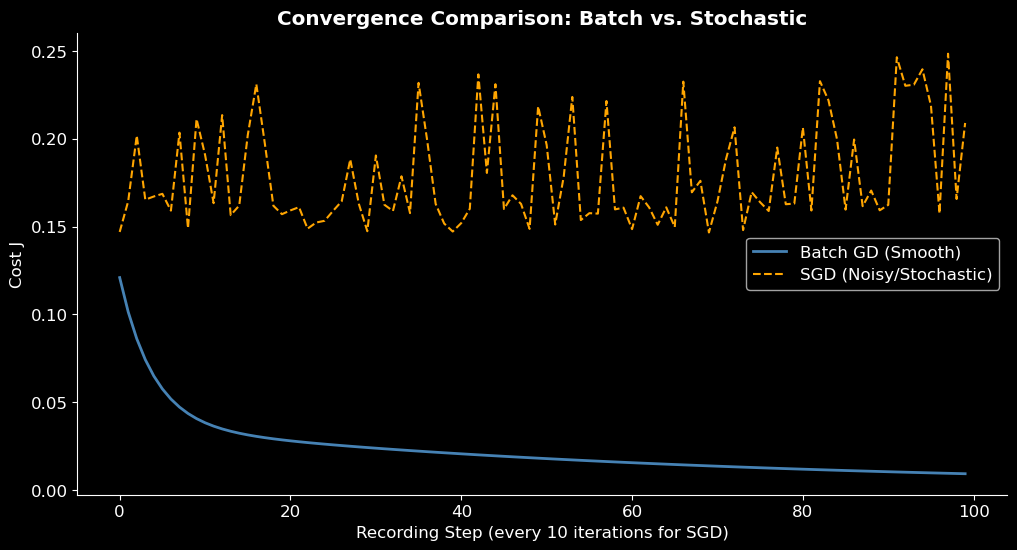

In [35]:
# 🌟 BONUS — Stochastic Gradient Descent class

class SGDLinearRegression:
    """Linear Regression with Stochastic Gradient Descent (1 sample per update)."""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.cost_history = []

    def fit(self, X, y):
        m = len(y)
        for i in range(self.n_iter):
            
            # Pick ONE random sample index
            
            idx = np.random.randint(0, m)
            xi  = X[idx]
            yi  = y[idx]

            # YOUR CODE HERE — compute prediction and error for just sample idx
            
            pred  = self.theta0 + self.theta1 * xi
            error = pred - yi

            # YOUR CODE HERE — gradient for 1 sample (no 1/m average needed)
            
            grad0 = error
            grad1 = error * xi

            # YOUR CODE HERE — simultaneous update
            
            self.theta0 = self.lr * grad0
            self.theta1 = self.lr * grad1

            # Record full batch cost every 10 steps (for comparison)
            
            if i % 10 == 0:
                full_cost = (1/(2*m)) * np.sum((self.theta0 + self.theta1*X - y)**2)
                self.cost_history.append(full_cost)

        return self


# ── Compare SGD vs Batch GD cost curves ──────────────────────────────
# YOUR CODE HERE — train both, plot side by side

# Train Batch GD (from your previous work)

batch_model = LinearRegressionGD(learning_rate=0.1, n_iterations=1000)
batch_model.fit(X_train, y_train)

# Train SGD

sgd_model = SGDLinearRegression(learning_rate=0.1, n_iterations=1000)
sgd_model.fit(X_train, y_train)

# Plotting the Comparison

plt.figure(figsize=(12, 6))
plt.plot(batch_model.cost_history[:100], label='Batch GD (Smooth)', color='steelblue', linewidth=2)
plt.plot(sgd_model.cost_history[:100], label='SGD (Noisy/Stochastic)', color='orange', linestyle='--')
plt.title("Convergence Comparison: Batch vs. Stochastic", fontweight='bold')
plt.xlabel("Recording Step (every 10 iterations for SGD)")
plt.ylabel("Cost J")
plt.legend()
plt.show()


---
## ✅ Summary — What You Built

Congratulations! Here's what you implemented from scratch:

| Component | Formula |
|---|---|
| **Hypothesis** | hθ(x) = θ₀ + θ₁x |
| **Cost** | J = (1/2m) Σ (hθ(xⁱ) − yⁱ)² |
| **Gradient θ₀** | ∂J/∂θ₀ = (1/m) Σ (hθ(xⁱ) − yⁱ) |
| **Gradient θ₁** | ∂J/∂θ₁ = (1/m) Σ (hθ(xⁱ) − yⁱ) · xⁱ |
| **Update rule** | θ := θ − α · ∂J/∂θ |

Your gradient descent model should achieve **R² ≥ 0.95** on this dataset — almost identical to sklearn's closed-form solution! 🎉

---
*This notebook was built to accompany the Linear Regression lecture. Keep it as a reference for future implementations.*
